In [3]:
import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/TIKILR')

Set up the model code

In [2]:
os.getcwd()

'/content'

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 1. Forward Model & Energy
# -----------------------------------------------------------------------------

def biexponential(t, x):
    """x = [c0, c1, lam0, lam1]"""
    c, lam = x[:2], x[2:]
    return c[0]*torch.exp(-lam[0]*t) + c[1]*torch.exp(-lam[1]*t)

def energy_function(x, y, t, mu):
    """The lower-level objective: E = 0.5 * ||G(x) - y||^2 + 0.5 * mu * ||x||^2"""
    residual = y - biexponential(t, x)
    return 0.5 * torch.sum(residual**2) + 0.5 * mu * torch.sum(x**2)

In [9]:
def solve_ep_multiexp(y_obs, x_true, t, mu_init=0.5, n_outer=50):
    """
    Solves the bilevel problem:
    Upper: min_mu 0.5 * ||x_hat(mu) - x_true||^2
    Lower: min_x  0.5 * ||G(x) - y_obs||^2 + 0.5 * mu * ||x||^2
    """
    mu = torch.tensor(mu_init, requires_grad=False)
    # State initialization [c0, c1, lam0, lam1]
    x = torch.tensor([0.5, 0.5, 1.0, 1.0], requires_grad=True)

    # Hyperparameters for EP
    beta = 0.01       # Nudge factor
    eta_x = 0.005     # State learning rate (relaxation)
    eta_mu = 0.02     # mu learning rate
    inner_steps = 400 # Steps to reach equilibrium

    history = {"mu": [], "loss_upper": []}

    for outer in range(n_outer):
        # --- PHASE 1: Free Phase (Find x^0) ---
        # We find the equilibrium of the lower-level energy
        for _ in range(inner_steps):
            E = energy_function(x, y_obs, t, mu)
            grad_x = torch.autograd.grad(E, x)[0]
            with torch.no_grad():
                x -= eta_x * grad_x
                x.clamp_(min=1e-6) # Projected Gradient Descent (c, lam > 0)

        x0 = x.clone().detach()

        # --- PHASE 2: Nudged Phase (Find x^beta) ---
        # We add a small nudge from the upper-level loss: L = 0.5 * ||x - x_true||^2
        for _ in range(inner_steps):
            E_total = energy_function(x, y_obs, t, mu)
            L_upper = 0.5 * torch.sum((x - x_true)**2)

            # Total Gradient = grad(Energy) + beta * grad(Upper Loss)
            grad_total = torch.autograd.grad(E_total + beta * L_upper, x)[0]

            with torch.no_grad():
                x -= eta_x * grad_total
                x.clamp_(min=1e-6)

        x_beta = x.clone().detach()

        # --- PHASE 3: Update mu using EP Rule ---
        # dL/dmu = (1/beta) * ( dE/dmu(x_beta) - dE/dmu(x0) )
        # Since dE/dmu = 0.5 * ||x||^2:
        grad_mu = (1.0 / (2.0 * beta)) * (torch.sum(x_beta**2) - torch.sum(x0**2))

        with torch.no_grad():
            mu = mu - eta_mu * grad_mu
            mu.clamp_(min=1e-5) # Ensure mu stays positive

        # Logging
        upper_val = 0.5 * torch.sum((x0 - x_true)**2).item()
        history["mu"].append(mu.item())
        history["loss_upper"].append(upper_val)

        if outer % 100 == 0:
            print(f"Iter {outer:02d} | mu: {mu.item():.4f} | MSE: {upper_val:.6f}")

    return x0, mu, history

compute!

In [10]:
# Setup problem
t = torch.linspace(0.05, 3.0, 60)
x_true = torch.tensor([0.7, 0.3, 0.4, 2.5]) # [c0, c1, lam0, lam1]
y_clean = biexponential(t, x_true)
y_obs = y_clean + 0.05 * torch.randn_like(y_clean) # Gaussian noise case

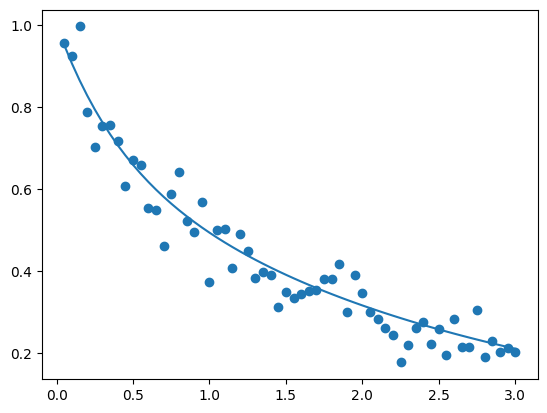

In [11]:
plt.scatter(t, y_obs, label="Observed")
plt.plot(t, y_clean, label="True")

In [12]:
# solve
x_final, mu_final, hist = solve_ep_multiexp(y_obs, x_true, t, n_outer=1000)

Iter 00 | mu: 0.4951 | MSE: 2.136240
Iter 100 | mu: 0.0000 | MSE: 0.017475
Iter 200 | mu: 1.5647 | MSE: 2.396260
Iter 300 | mu: 1.1381 | MSE: 2.305562
Iter 400 | mu: 0.6074 | MSE: 2.162755
Iter 500 | mu: 0.0000 | MSE: 0.092767
Iter 600 | mu: 0.7843 | MSE: 2.215618
Iter 700 | mu: 0.0000 | MSE: 0.884016
Iter 800 | mu: 0.0003 | MSE: 0.010696
Iter 900 | mu: 1.3430 | MSE: 2.351112


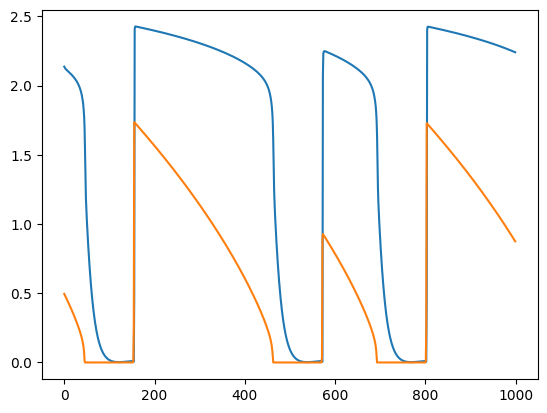

In [16]:
plt.plot(hist["loss_upper"])
plt.plot(hist["mu"])